In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

sns.set_style("whitegrid")
plt.rcParams["figure.figsize"] = (6, 3)

df = pd.read_csv("../transaction_data.csv")

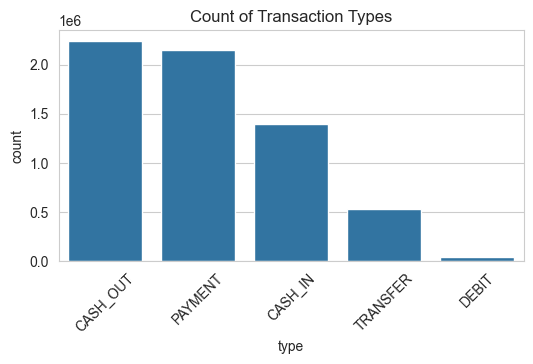

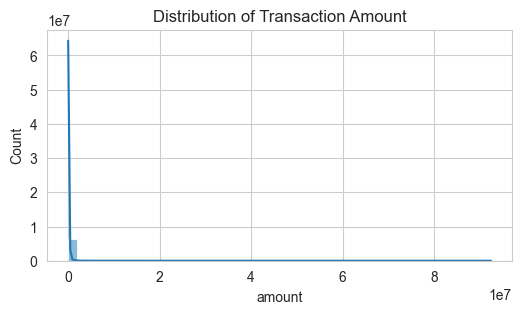

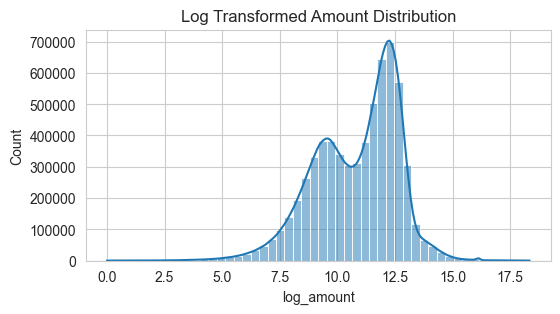

In [2]:
# Univariate analysis

# Transaction type frequency
df["type"].value_counts()

sns.countplot(x="type", data=df, order=df["type"].value_counts().index)
plt.title("Count of Transaction Types")
plt.xticks(rotation=45)
plt.show()

#  Amount distribution
sns.histplot(df["amount"], bins=50, kde=True)
plt.title("Distribution of Transaction Amount")
plt.show()

# Log amount distribution
df["log_amount"] = np.log1p(df["amount"])
sns.histplot(df["log_amount"], bins=50, kde=True)
plt.title("Log Transformed Amount Distribution")
plt.show()

isFraud         0     1
type                   
CASH_IN   1399284     0
CASH_OUT  2233384  4116
DEBIT       41432     0
PAYMENT   2151495     0
TRANSFER   528812  4097
isFraud            0         1
type                          
CASH_IN   100.000000  0.000000
CASH_OUT   99.816045  0.183955
DEBIT     100.000000  0.000000
PAYMENT   100.000000  0.000000
TRANSFER   99.231201  0.768799


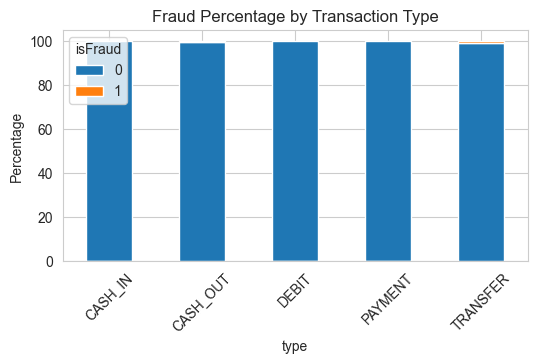

In [3]:
# Fraud vs Transaction Type
fraud_type = pd.crosstab(df["type"], df["isFraud"])
print(fraud_type)

fraud_type_norm = pd.crosstab(df["type"], df["isFraud"], normalize="index") * 100
print(fraud_type_norm)

fraud_type_norm.plot(kind="bar", stacked=True)
plt.title("Fraud Percentage by Transaction Type")
plt.ylabel("Percentage")
plt.xticks(rotation=45)
plt.show()

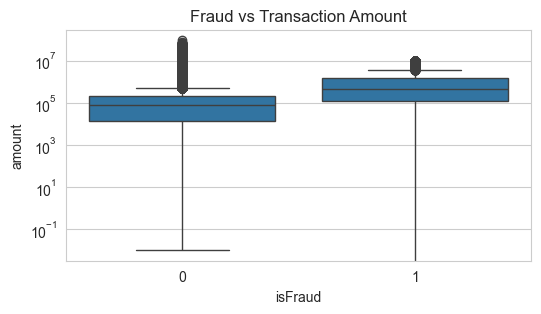

,count,mean,std,min,25%,50%,75%,max
isFraud,,,,,,,,
0,6354407.0,1.781970e+05,5.962370e+05,0.01,13368.395,74684.72,208364.76,92445516.64
1,8213.0,1.467967e+06,2.404253e+06,0.00,127091.330,441423.44,1517771.48,10000000.00


In [4]:
# Fraud vs Amount
sns.boxplot(x="isFraud", y="amount", data=df)
plt.title("Fraud vs Transaction Amount")
plt.yscale("log")
plt.show()

df.groupby("isFraud")["amount"].describe()

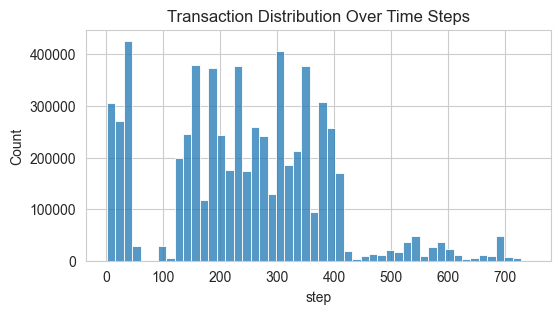

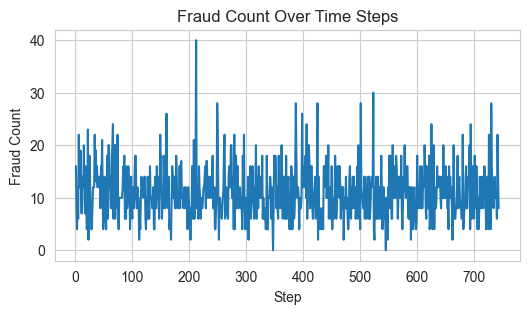

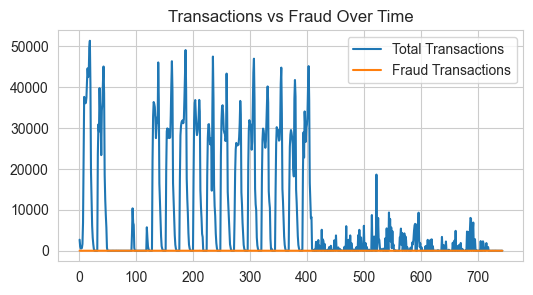

In [5]:
# Time-based analysis using
sns.histplot(df["step"], bins=50)
plt.title("Transaction Distribution Over Time Steps")
plt.show()

fraud_by_step = df.groupby("step")["isFraud"].sum()

plt.plot(fraud_by_step.index, fraud_by_step.values)
plt.title("Fraud Count Over Time Steps")
plt.xlabel("Step")
plt.ylabel("Fraud Count")
plt.show()

transactions_by_step = df.groupby("step").size()
fraud_by_step = df.groupby("step")["isFraud"].sum()

plt.plot(transactions_by_step.index, transactions_by_step.values, label="Total Transactions")
plt.plot(fraud_by_step.index, fraud_by_step.values, label="Fraud Transactions")
plt.legend()
plt.title("Transactions vs Fraud Over Time")
plt.show()

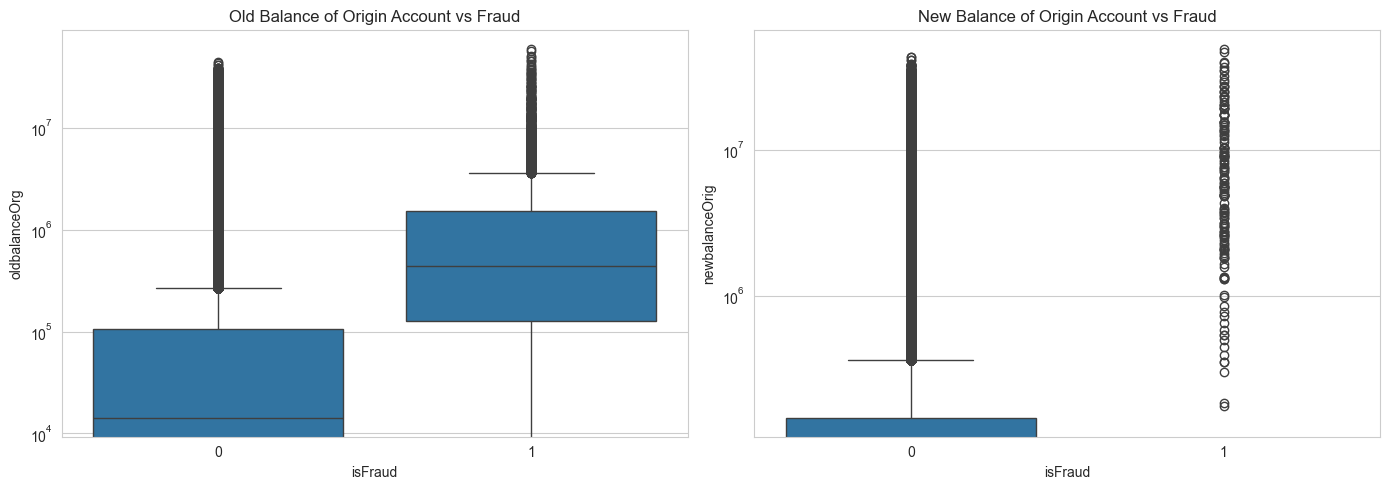

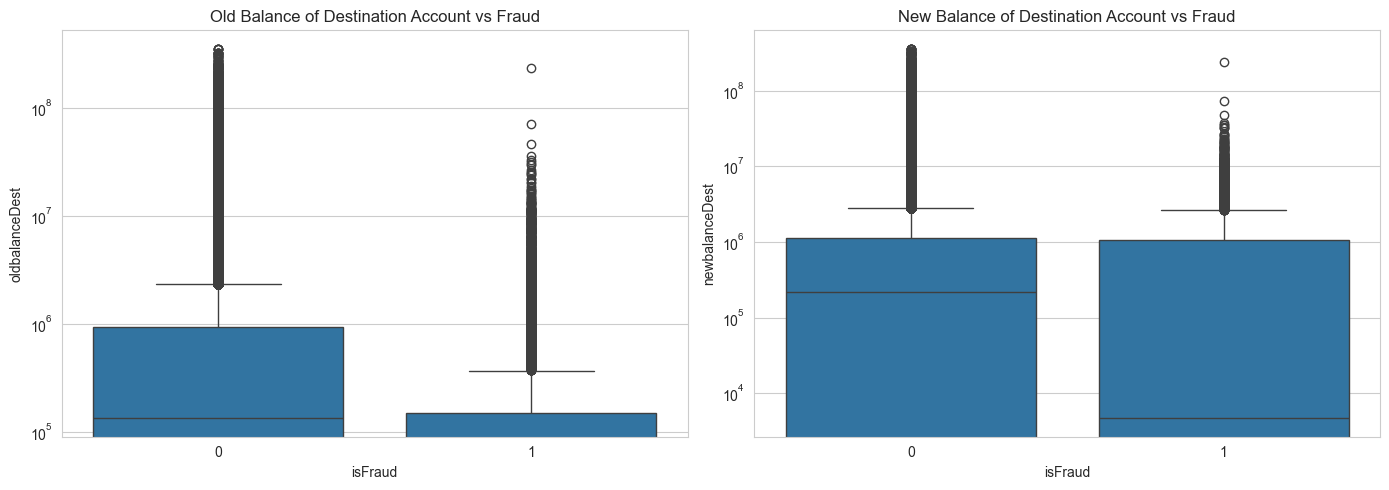

In [6]:
# Balance feature analysis

# Sender balance comparison
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

sns.boxplot(x="isFraud", y="oldbalanceOrg", data=df, ax=axes[0])
axes[0].set_title("Old Balance of Origin Account vs Fraud")
axes[0].set_yscale("log")

sns.boxplot(x="isFraud", y="newbalanceOrig", data=df, ax=axes[1])
axes[1].set_title("New Balance of Origin Account vs Fraud")
axes[1].set_yscale("log")

plt.tight_layout()
plt.show()

# Destination balance comparison
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

sns.boxplot(x="isFraud", y="oldbalanceDest", data=df, ax=axes[0])
axes[0].set_title("Old Balance of Destination Account vs Fraud")
axes[0].set_yscale("log")

sns.boxplot(x="isFraud", y="newbalanceDest", data=df, ax=axes[1])
axes[1].set_title("New Balance of Destination Account vs Fraud")
axes[1].set_yscale("log")

plt.tight_layout()
plt.show()

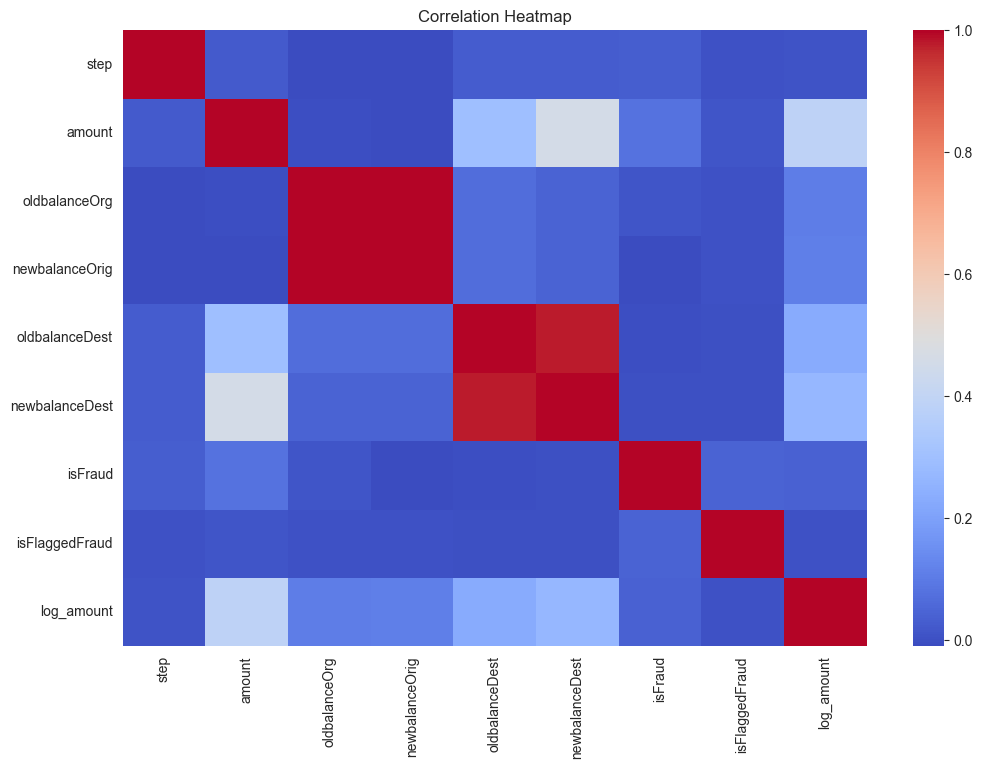

isFraud           1.000000
amount            0.076688
isFlaggedFraud    0.044109
log_amount        0.040640
step              0.031578
oldbalanceOrg     0.010154
newbalanceDest    0.000535
oldbalanceDest   -0.005885
newbalanceOrig   -0.008148
Name: isFraud, dtype: float64

In [7]:
# Correlation analysis
num_df = df.select_dtypes(include=np.number)

corr = num_df.corr()

plt.figure(figsize=(12, 8))
sns.heatmap(corr, cmap="coolwarm", annot=False)
plt.title("Correlation Heatmap")
plt.show()

corr["isFraud"].sort_values(ascending=False)

In [8]:
# Fraud-specific subset analysis
fraud_df = df[df["isFraud"] == 1]
non_fraud_df = df[df["isFraud"] == 0]

print("Fraud Transactions:", fraud_df.shape)
print("Non-Fraud Transactions:", non_fraud_df.shape)

fraud_df["type"].value_counts()

fraud_df["amount"].describe()

Fraud Transactions: (8213, 12)
Non-Fraud Transactions: (6354407, 12)


count    8.213000e+03
mean     1.467967e+06
std      2.404253e+06
min      0.000000e+00
25%      1.270913e+05
50%      4.414234e+05
75%      1.517771e+06
max      1.000000e+07
Name: amount, dtype: float64

In [9]:
# Analyze 
pd.crosstab(df["isFlaggedFraud"], df["isFraud"])

isFraud,0,1
isFlaggedFraud,,
0,6354407,8197
1,0,16


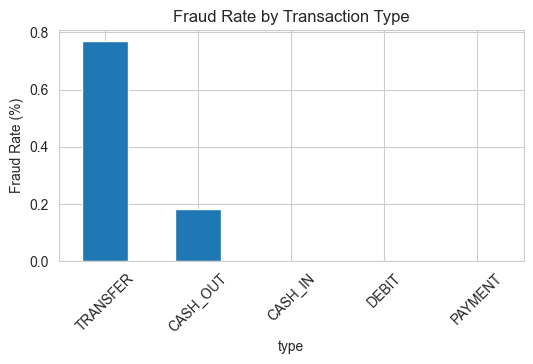

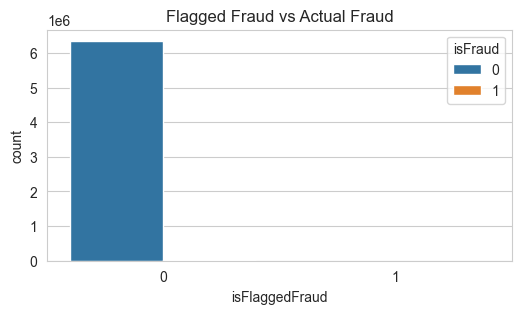

In [11]:
# Fraud rate by transaction type
fraud_rate_by_type = df.groupby("type")["isFraud"].mean().sort_values(ascending=False) * 100
fraud_rate_by_type.plot(kind="bar")
plt.title("Fraud Rate by Transaction Type")
plt.ylabel("Fraud Rate (%)")
plt.xticks(rotation=45)
plt.show()

# Compare flagged vs fraud
sns.countplot(x="isFlaggedFraud", hue="isFraud", data=df)
plt.title("Flagged Fraud vs Actual Fraud")
plt.show()